# StepUp AI 

Arsitektur yang digunakan:

1. **Core Recommendation System**  
   TF-IDF + Cosine Similarity untuk menghasilkan **Top-3 career recommendation**.

2. **Deep Learning Component**  
   TensorFlow Functional API untuk mempelajari **match_score** sebagai skor kecocokan user-job.  

3. **Output aplikasi**
   - Top-3 career recommendation
   - match score
   - hard skill gap
   - soft skill gap
   - ATS-ready CV
   - GenAI explanation

## 1. Import Library

Library utama:
- `pandas`, `numpy` untuk data
- `sklearn` untuk TF-IDF, cosine similarity, split, metric
- `tensorflow` untuk deep learning
- `pickle/json` untuk export artifact

In [21]:
import os
import ast
import json
import pickle
import datetime
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_absolute_error, accuracy_score

import tensorflow as tf
from tensorflow.keras import layers, regularizers

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## 2. Load Dataset

In [22]:
DATA_PATHS = [
    "/mnt/data/dataset_with_features(1).csv",
    "/mnt/data/dataset_with_features.csv",
    "dataset_with_features.csv"
]

DATA_PATH = None
for p in DATA_PATHS:
    if Path(p).exists():
        DATA_PATH = p
        break

if DATA_PATH is None:
    raise FileNotFoundError("dataset_with_features.csv tidak ditemukan. Upload file dataset terlebih dahulu.")

df = pd.read_csv(DATA_PATH)
print("Dataset path:", DATA_PATH)
print("Shape:", df.shape)
df.head()

Dataset path: dataset_with_features.csv
Shape: (9888, 12)


,resume_text,job_role,education,category,education_requirement,soft_skills_user,required_soft_skills,hard_skills_user,required_hard_skills_user,matched_skills,skill_gap,match_score
0,education: bachelor's in civil engineering exp...,geotechnical engineer,bachelor's in civil engineering,engineering,bachelor's in civil engineering,"['critical thinking', 'responsibility', 'profe...","['analysis', 'critical thinking', 'precision']","['technical drawing', 'structural analysis', '...","['structural analysis', 'building codes', 'tec...","['critical thinking', 'structural analysis', '...","['analysis', 'precision']",0.73
1,education: bachelor's in marketing experience:...,email marketing specialist,bachelor's in marketing,economy,bachelor's in marketing,"['attention to detail', 'communication', 'crea...","['communication', 'creativity', 'attention to ...","['copywriting', 'crm', 'financial analysis', '...","['copywriting', 'crm', 'campaign management']","['attention to detail', 'crm', 'copywriting', ...",['campaign management'],0.87
2,education: bachelor's in robotics engineering ...,robotics engineer,bachelor's in robotics engineering,engineering,bachelor's in robotics engineering,"['problem solving', 'strategic thinking', 'qui...","['creativity', 'problem solving', 'strategic t...","['microcontrollers', 'embedded systems', 'elec...","['embedded systems', 'microcontrollers', 'matl...","['problem solving', 'strategic thinking', 'emb...","['matlab', 'creativity']",0.73
3,education: bachelor's in business experience: ...,sales manager,bachelor's in business,economy,bachelor's in business,['business acumen'],"['business acumen', 'planning']",['crm'],['crm'],"['business acumen', 'crm']",['planning'],0.73
4,education: bachelor's in multimedia experience...,fashion designer,bachelor's in multimedia,creative_design,bachelor's in fashion design|creative design c...,"['strategic planning', 'critical thinking', 'p...","['budget control', 'teamwork', 'business acumen']","['rendering', 'texturing']","['rendering', 'adobe creative suite']","['teamwork', 'rendering', 'budget control']","['business acumen', 'adobe creative suite']",0.48


## 3. Validasi Kolom Dataset


In [23]:
required_columns = [
    "resume_text",
    "job_role",
    "education",
    "category",
    "education_requirement",
    "soft_skills_user",
    "required_soft_skills",
    "hard_skills_user",
    "required_hard_skills_user",
    "matched_skills",
    "skill_gap",
    "match_score"
]

missing = [col for col in required_columns if col not in df.columns]
if missing:
    raise ValueError(f"Kolom berikut tidak ditemukan: {missing}")

print("Semua kolom wajib tersedia.")
print(df.columns.tolist())

Semua kolom wajib tersedia.
['resume_text', 'job_role', 'education', 'category', 'education_requirement', 'soft_skills_user', 'required_soft_skills', 'hard_skills_user', 'required_hard_skills_user', 'matched_skills', 'skill_gap', 'match_score']


## 4. Helper Function

Fungsi ini digunakan untuk:
- mengubah string list menjadi list Python
- membersihkan teks
- menggabungkan list skill menjadi string

In [24]:
def safe_parse_list(value):
    if isinstance(value, list):
        return value
    if pd.isna(value):
        return []
    if isinstance(value, str):
        value = value.strip()
        try:
            parsed = ast.literal_eval(value)
            if isinstance(parsed, list):
                return [str(x).strip().lower() for x in parsed if str(x).strip()]
        except Exception:
            return [x.strip().lower() for x in value.split(",") if x.strip()]
    return []


def clean_text(text):
    if pd.isna(text):
        return ""
    return str(text).lower().replace("\n", " ").strip()


def list_to_text(items):
    if not isinstance(items, list):
        return ""
    return " ".join([str(x).lower().strip() for x in items if str(x).strip()])


def skill_gap_by_type(user_skills, required_skills):
    user_set = set([s.lower().strip() for s in user_skills])
    req_set = set([s.lower().strip() for s in required_skills])
    matched = sorted(list(user_set & req_set))
    missing = sorted(list(req_set - user_set))
    score = len(matched) / len(req_set) if req_set else 0
    return {
        "matched": matched,
        "missing": missing,
        "score": round(score * 100, 2)
    }

## 5. Cleaning dan Feature Preparation

In [25]:
list_columns = [
    "soft_skills_user",
    "required_soft_skills",
    "hard_skills_user",
    "required_hard_skills_user",
    "matched_skills",
    "skill_gap"
]

for col in list_columns:
    df[col + "_list"] = df[col].apply(safe_parse_list)

for col in ["resume_text", "job_role", "education", "category", "education_requirement"]:
    df[col] = df[col].apply(clean_text)

df["user_profile_text"] = (
    df["resume_text"].fillna("") + " " +
    df["education"].fillna("") + " " +
    df["hard_skills_user_list"].apply(list_to_text) + " " +
    df["soft_skills_user_list"].apply(list_to_text)
)

df["job_profile_text"] = (
    df["job_role"].fillna("") + " " +
    df["category"].fillna("") + " " +
    df["education_requirement"].fillna("") + " " +
    df["required_hard_skills_user_list"].apply(list_to_text) + " " +
    df["required_soft_skills"].apply(clean_text)
)

df["match_score"] = pd.to_numeric(df["match_score"], errors="coerce").fillna(0).clip(0, 1)

print(df[["user_profile_text", "job_profile_text", "match_score"]].head())

                                   user_profile_text  \
0  education: bachelor's in civil engineering exp...   
1  education: bachelor's in marketing experience:...   
2  education: bachelor's in robotics engineering ...   
3  education: bachelor's in business experience: ...   
4  education: bachelor's in multimedia experience...   

                                    job_profile_text  match_score  
0  geotechnical engineer engineering bachelor's i...         0.73  
1  email marketing specialist economy bachelor's ...         0.87  
2  robotics engineer engineering bachelor's in ro...         0.73  
3  sales manager economy bachelor's in business c...         0.73  
4  fashion designer creative_design bachelor's in...         0.48  


## 6. TF-IDF + Cosine Similarity

In [26]:
# Buat katalog job unik agar rekomendasi tidak berulang terlalu banyak
job_catalog = (
    df.groupby(["job_role", "category"], as_index=False)
      .agg({
          "job_profile_text": "first",
          "required_hard_skills_user_list": "first",
          "required_soft_skills_list": "first",
          "education_requirement": "first"
      })
)

tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=1
)

job_tfidf_matrix = tfidf_vectorizer.fit_transform(job_catalog["job_profile_text"])

print("Jumlah job role unik:", len(job_catalog))
print("TF-IDF matrix shape:", job_tfidf_matrix.shape)

Jumlah job role unik: 116
TF-IDF matrix shape: (116, 1088)


## 7. Fungsi Top-3 Recommendation


In [27]:
def build_user_text(user_profile):
    hard_skills = user_profile.get("hard_skills", [])
    soft_skills = user_profile.get("soft_skills", [])
    projects = user_profile.get("projects", [])
    internships = user_profile.get("internships", [])
    organizations = user_profile.get("organizations", [])
    certifications = user_profile.get("certifications", [])

    text_parts = [
        user_profile.get("major", ""),
        user_profile.get("education", ""),
        " ".join(hard_skills),
        " ".join(soft_skills),
        " ".join(projects),
        " ".join(internships),
        " ".join(organizations),
        " ".join(certifications),
    ]
    return clean_text(" ".join(text_parts))


def recommend_top3(user_profile, top_n=3):
    user_text = build_user_text(user_profile)
    user_vec = tfidf_vectorizer.transform([user_text])

    scores = cosine_similarity(user_vec, job_tfidf_matrix).flatten()
    top_indices = scores.argsort()[::-1][:top_n]

    recommendations = []
    user_hard = [s.lower().strip() for s in user_profile.get("hard_skills", [])]
    user_soft = [s.lower().strip() for s in user_profile.get("soft_skills", [])]

    for idx in top_indices:
        row = job_catalog.iloc[idx]
        required_hard = row["required_hard_skills_user_list"]
        required_soft = row["required_soft_skills_list"]

        hard_gap = skill_gap_by_type(user_hard, required_hard)
        soft_gap = skill_gap_by_type(user_soft, required_soft)

        recommendations.append({
            "job_role": row["job_role"],
            "category": row["category"],
            "cosine_score": round(float(scores[idx]) * 100, 2),
            "hard_skill_gap": hard_gap,
            "soft_skill_gap": soft_gap,
            "required_hard_skills": required_hard,
            "required_soft_skills": required_soft
        })

    return recommendations

## 8. Coba Recommendation

Bagian ini untuk melihat hasil rekomendasi yang akan ditampilkan di web.

In [28]:
# Sample user untuk inference akhir.
# Catatan: cell ini hanya mendefinisikan input user.
# Output final recommendation akan dijalankan setelah model selesai training dan evaluation.

sample_user = {
    "name": "Dimas Saputra",
    "email": "dimas.saputra@gmail.com",
    "phone": "+62 81234567890",
    "linkedin": "https://linkedin.com/in/dimassaputra",
    "location": "Bandung, Indonesia",
    "major": "Mechanical Engineering",
    "education": "Bachelor of Mechanical Engineering",
    "semester": 5,
    "gpa": 3.45,
    "hard_skills": [
        "autocad",
        "technical drawing",
        "matlab"
    ],
    "soft_skills": [
        "problem solving",
        "teamwork",
        "communication"
    ],
    "projects": [
        "mechanical component design project",
        "vehicle system analysis"
    ],
    "internships": [
        "mechanical engineering intern"
    ],
    "organizations": [
        "engineering student association"
    ],
    "certifications": [
        "AutoCAD basic certification"
    ]
}

print("Sample user sudah disiapkan. Jalankan inference akhir setelah model selesai training.")

Sample user sudah disiapkan. Jalankan inference akhir setelah model selesai training.


# Deep Learning Component

## 9. Prepare Data Untuk Deep Learning

Input model:
- TF-IDF user profile
- TF-IDF job profile
- engineered numeric features:
  - jumlah matched skills
  - jumlah skill gap
  - jumlah hard skill user
  - jumlah required hard skill
  - jumlah soft skill user
  - jumlah required soft skill

Target:
- `match_score` dari dataset

In [29]:
dl_vectorizer = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 2),
    min_df=1
)

all_text = pd.concat([df["user_profile_text"], df["job_profile_text"]], axis=0)
dl_vectorizer.fit(all_text)

X_user_text = dl_vectorizer.transform(df["user_profile_text"]).toarray().astype("float32")
X_job_text = dl_vectorizer.transform(df["job_profile_text"]).toarray().astype("float32")

numeric_features = np.column_stack([
    df["matched_skills_list"].apply(len).values,
    df["skill_gap_list"].apply(len).values,
    df["hard_skills_user_list"].apply(len).values,
    df["required_hard_skills_user_list"].apply(len).values,
    df["soft_skills_user_list"].apply(len).values,
    df["required_soft_skills_list"].apply(len).values,
]).astype("float32")

# Normalisasi sederhana numeric features
numeric_max = np.maximum(numeric_features.max(axis=0), 1)
X_num = numeric_features / numeric_max

y = df["match_score"].values.astype("float32").reshape(-1, 1)

print("X_user_text:", X_user_text.shape)
print("X_job_text:", X_job_text.shape)
print("X_num:", X_num.shape)
print("y:", y.shape)
print("Match score range:", y.min(), y.max())

X_user_text: (9888, 3000)
X_job_text: (9888, 3000)
X_num: (9888, 6)
y: (9888, 1)
Match score range: 0.32 1.0


## 10. Train / Validation / Test Split

Data dibagi menjadi 70% train, 15% validation, 15% test. 

In [30]:
score_bins = pd.cut(df["match_score"], bins=[0, 0.5, 0.7, 0.85, 1.0], labels=False, include_lowest=True)
use_stratify = pd.Series(score_bins).value_counts().min() >= 2

indices = np.arange(len(df))

train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.30,
    random_state=42,
    stratify=score_bins if use_stratify else None
)

temp_bins = score_bins.iloc[temp_idx] if hasattr(score_bins, "iloc") else score_bins[temp_idx]

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    random_state=42,
    stratify=temp_bins if pd.Series(temp_bins).value_counts().min() >= 2 else None
)

X_user_train, X_user_val, X_user_test = X_user_text[train_idx], X_user_text[val_idx], X_user_text[test_idx]
X_job_train, X_job_val, X_job_test = X_job_text[train_idx], X_job_text[val_idx], X_job_text[test_idx]
X_num_train, X_num_val, X_num_test = X_num[train_idx], X_num[val_idx], X_num[test_idx]
y_train, y_val, y_test = y[train_idx], y[val_idx], y[test_idx]

print("Train:", X_user_train.shape, y_train.shape)
print("Val:", X_user_val.shape, y_val.shape)
print("Test:", X_user_test.shape, y_test.shape)

Train: (6921, 3000) (6921, 1)
Val: (1483, 3000) (1483, 1)
Test: (1484, 3000) (1484, 1)


## 11. Custom Component
 
1. `L2NormalizeLayer` sebagai custom layer
2. `WeightedMAELoss` sebagai custom loss sederhana
3. `MinimumEpochEarlyStopper` sebagai custom callback manual

In [31]:
@tf.keras.utils.register_keras_serializable(package="StepUp")
class L2NormalizeLayer(tf.keras.layers.Layer):
    def call(self, inputs):
        return tf.math.l2_normalize(inputs, axis=1)

    def get_config(self):
        return super().get_config()


@tf.keras.utils.register_keras_serializable(package="StepUp")
class WeightedMAELoss(tf.keras.losses.Loss):
    def __init__(self, name="weighted_mae_loss"):
        super().__init__(name=name)

    def call(self, y_true, y_pred):
        weights = 1.0 + y_true
        return tf.reduce_mean(weights * tf.abs(y_true - y_pred))


class MinimumEpochEarlyStopper:
    def __init__(self, min_epochs=8, patience=5):
        self.min_epochs = min_epochs
        self.patience = patience
        self.best_val_loss = np.inf
        self.wait = 0
        self.stop_training = False

    def step(self, epoch, val_loss):
        if val_loss < self.best_val_loss:
            self.best_val_loss = val_loss
            self.wait = 0
            return True
        else:
            self.wait += 1

        if (epoch + 1) >= self.min_epochs and self.wait >= self.patience:
            self.stop_training = True

        return False

## 12. Build Deep Learning Model — TensorFlow Functional API

In [32]:
def build_deep_scoring_model(text_dim, num_dim):
    user_input = tf.keras.Input(shape=(text_dim,), name="user_tfidf_input")
    job_input = tf.keras.Input(shape=(text_dim,), name="job_tfidf_input")
    num_input = tf.keras.Input(shape=(num_dim,), name="numeric_feature_input")

    # Shared encoder agar user dan job berada pada ruang representasi yang sama
    shared_dense_1 = layers.Dense(
        64,
        activation="relu",
        kernel_regularizer=regularizers.l2(1e-4),
        name="shared_dense_1"
    )
    shared_dropout = layers.Dropout(0.35, name="shared_dropout")
    shared_dense_2 = layers.Dense(
        32,
        activation="relu",
        kernel_regularizer=regularizers.l2(1e-4),
        name="shared_dense_2"
    )
    l2_norm = L2NormalizeLayer(name="l2_normalize")

    user_emb = shared_dense_1(user_input)
    user_emb = shared_dropout(user_emb)
    user_emb = shared_dense_2(user_emb)
    user_emb = l2_norm(user_emb)

    job_emb = shared_dense_1(job_input)
    job_emb = shared_dropout(job_emb)
    job_emb = shared_dense_2(job_emb)
    job_emb = l2_norm(job_emb)

    similarity = layers.Dot(axes=1, name="embedding_similarity")([user_emb, job_emb])

    x = layers.Concatenate(name="concat_similarity_numeric")([similarity, num_input])
    x = layers.Dense(32, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.25)(x)
    output = layers.Dense(1, activation="sigmoid", name="predicted_match_score")(x)

    model = tf.keras.Model(
        inputs=[user_input, job_input, num_input],
        outputs=output,
        name="stepup_match_score_regression_model"
    )
    return model


text_dim = X_user_train.shape[1]
num_dim = X_num_train.shape[1]

model = build_deep_scoring_model(text_dim, num_dim)
model.summary()

Model: "stepup_match_score_regression_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user_tfidf_input    │ (None, 3000)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ job_tfidf_input     │ (None, 3000)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_dense_1      │ (None, 64)        │    192,064 │ user_tfidf_input… │
│ (Dense)             │                   │            │ job_tfidf_input[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_dropout      │ (None, 64)        │          0 │ shared_dense_1[0… │
│ (Dropout)           │                   │            │ shared_dense_1[1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_dense_2      │ (None, 32)        │      2,080 │ shared_dropout[0… │
│ (Dense)             │                   │            │ shared_dropout[1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ l2_normalize        │ (None, 32)        │          0 │ shared_dense_2[0… │
│ (L2NormalizeLayer)  │                   │            │ shared_dense_2[1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_similari… │ (None, 1)         │          0 │ l2_normalize[0][… │
│ (Dot)               │                   │            │ l2_normalize[1][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numeric_feature_in… │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_similarity_… │ (None, 7)         │          0 │ embedding_simila… │
│ (Concatenate)       │                   │            │ numeric_feature_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │        256 │ concat_similarit… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ predicted_match_sc… │ (None, 1)         │         33 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 194,433 (759.50 KB)

 Trainable params: 194,433 (759.50 KB)

 Non-trainable params: 0 (0.00 B)

## 13. Custom Training Loop dengan `tf.GradientTape` + TensorBoard

In [33]:
BATCH_SIZE = 64
EPOCHS = 30
LEARNING_RATE = 1e-3
TOLERANCE = 0.10

train_ds = tf.data.Dataset.from_tensor_slices(
    ((X_user_train, X_job_train, X_num_train), y_train)
).shuffle(2048, seed=42).batch(BATCH_SIZE)

val_ds = tf.data.Dataset.from_tensor_slices(
    ((X_user_val, X_job_val, X_num_val), y_val)
).batch(BATCH_SIZE)

optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)
loss_fn = WeightedMAELoss()

train_loss_metric = tf.keras.metrics.Mean(name="train_loss")
train_mae_metric = tf.keras.metrics.MeanAbsoluteError(name="train_mae")
train_acc_metric = tf.keras.metrics.Mean(name="train_accuracy")

val_loss_metric = tf.keras.metrics.Mean(name="val_loss")
val_mae_metric = tf.keras.metrics.MeanAbsoluteError(name="val_mae")
val_acc_metric = tf.keras.metrics.Mean(name="val_accuracy")

log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
summary_writer = tf.summary.create_file_writer(log_dir)

early_stopper = MinimumEpochEarlyStopper(min_epochs=8, patience=5)

history = {
    "loss": [],
    "mae": [],
    "accuracy": [],
    "val_loss": [],
    "val_mae": [],
    "val_accuracy": []
}

def tolerance_accuracy(y_true, y_pred, tolerance=TOLERANCE):
    correct = tf.cast(tf.abs(y_true - y_pred) <= tolerance, tf.float32)
    return tf.reduce_mean(correct)

for epoch in range(EPOCHS):
    train_loss_metric.reset_state()
    train_mae_metric.reset_state()
    train_acc_metric.reset_state()

    val_loss_metric.reset_state()
    val_mae_metric.reset_state()
    val_acc_metric.reset_state()

    for (batch_user, batch_job, batch_num), batch_y in train_ds:
        with tf.GradientTape() as tape:
            preds = model([batch_user, batch_job, batch_num], training=True)
            loss_value = loss_fn(batch_y, preds)

        grads = tape.gradient(loss_value, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))

        train_loss_metric.update_state(loss_value)
        train_mae_metric.update_state(batch_y, preds)
        train_acc_metric.update_state(tolerance_accuracy(batch_y, preds))

    for (val_user, val_job, val_num), val_y in val_ds:
        val_preds = model([val_user, val_job, val_num], training=False)
        val_loss = loss_fn(val_y, val_preds)

        val_loss_metric.update_state(val_loss)
        val_mae_metric.update_state(val_y, val_preds)
        val_acc_metric.update_state(tolerance_accuracy(val_y, val_preds))

    logs = {
        "loss": float(train_loss_metric.result().numpy()),
        "mae": float(train_mae_metric.result().numpy()),
        "accuracy": float(train_acc_metric.result().numpy()),
        "val_loss": float(val_loss_metric.result().numpy()),
        "val_mae": float(val_mae_metric.result().numpy()),
        "val_accuracy": float(val_acc_metric.result().numpy())
    }

    for k, v in logs.items():
        history[k].append(v)

    with summary_writer.as_default():
        for k, v in logs.items():
            tf.summary.scalar(k, v, step=epoch)

    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} | "
        f"loss={logs['loss']:.4f} mae={logs['mae']:.4f} acc@0.10={logs['accuracy']:.4f} | "
        f"val_loss={logs['val_loss']:.4f} val_mae={logs['val_mae']:.4f} val_acc@0.10={logs['val_accuracy']:.4f}"
    )

    improved = early_stopper.step(epoch, logs["val_loss"])
    if improved:
        model.save("stepup_match_score_model.keras")

    if early_stopper.stop_training:
        print("Early stopping aktif.")
        break

print("TensorBoard log dir:", log_dir)
print("Jalankan TensorBoard dengan:")
print("%load_ext tensorboard")
print("%tensorboard --logdir logs/fit")

Epoch 01/30 | loss=0.2561 mae=0.1466 acc@0.10=0.4033 | val_loss=0.1593 val_mae=0.0955 val_acc@0.10=0.5893
Epoch 02/30 | loss=0.1377 mae=0.0798 acc@0.10=0.6836 | val_loss=0.0868 val_mae=0.0499 val_acc@0.10=0.8680
Epoch 03/30 | loss=0.1064 mae=0.0615 acc@0.10=0.8085 | val_loss=0.0686 val_mae=0.0391 val_acc@0.10=0.9096
Epoch 04/30 | loss=0.0900 mae=0.0519 acc@0.10=0.8733 | val_loss=0.0646 val_mae=0.0369 val_acc@0.10=0.9187
Epoch 05/30 | loss=0.0816 mae=0.0468 acc@0.10=0.9029 | val_loss=0.0602 val_mae=0.0345 val_acc@0.10=0.9324
Epoch 06/30 | loss=0.0758 mae=0.0435 acc@0.10=0.9201 | val_loss=0.0553 val_mae=0.0320 val_acc@0.10=0.9448
Epoch 07/30 | loss=0.0693 mae=0.0396 acc@0.10=0.9382 | val_loss=0.0509 val_mae=0.0293 val_acc@0.10=0.9565
Epoch 08/30 | loss=0.0655 mae=0.0376 acc@0.10=0.9481 | val_loss=0.0507 val_mae=0.0294 val_acc@0.10=0.9655
Epoch 09/30 | loss=0.0629 mae=0.0357 acc@0.10=0.9518 | val_loss=0.0478 val_mae=0.0278 val_acc@0.10=0.9643
Epoch 10/30 | loss=0.0595 mae=0.0340 acc@0.10=

## 13B. TensorBoard dan Visualisasi Metrik Training

Cell ini menambahkan visualisasi yang lebih jelas untuk memenuhi checkpoint **TensorBoard**.  
Metrik yang divisualisasikan:
- training loss dan validation loss
- training MAE dan validation MAE
- training accuracy dan validation accuracy
- learning rate

TensorBoard log dir: logs/fit/20260524-153552
Log TensorBoard sudah berisi train/loss, train/mae, train/accuracy, validation/loss, validation/mae, validation/accuracy, dan learning rate.


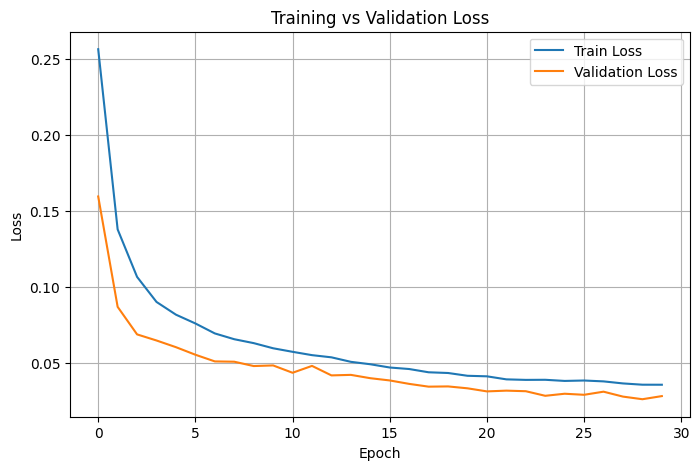

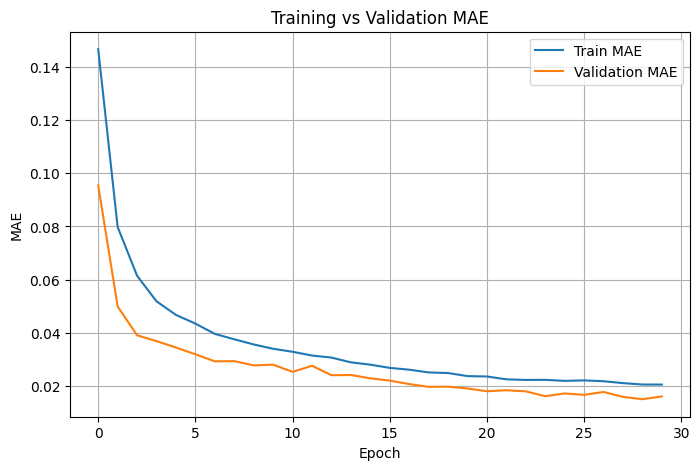

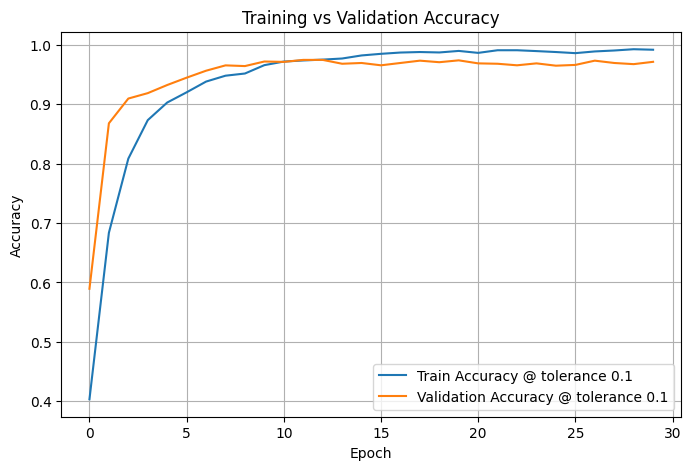

In [34]:

# TENSORBOARD LOGGING + TRAINING VISUALIZATION

import matplotlib.pyplot as plt

# Tambahkan grouped scalar agar tampilan TensorBoard lebih rapi
with summary_writer.as_default():
    for epoch_idx in range(len(history["loss"])):
        tf.summary.scalar("train/loss", history["loss"][epoch_idx], step=epoch_idx)
        tf.summary.scalar("train/mae", history["mae"][epoch_idx], step=epoch_idx)
        tf.summary.scalar("train/accuracy", history["accuracy"][epoch_idx], step=epoch_idx)

        tf.summary.scalar("validation/loss", history["val_loss"][epoch_idx], step=epoch_idx)
        tf.summary.scalar("validation/mae", history["val_mae"][epoch_idx], step=epoch_idx)
        tf.summary.scalar("validation/accuracy", history["val_accuracy"][epoch_idx], step=epoch_idx)

        tf.summary.scalar("training/learning_rate", LEARNING_RATE, step=epoch_idx)

summary_writer.flush()

print("TensorBoard log dir:", log_dir)
print("Log TensorBoard sudah berisi train/loss, train/mae, train/accuracy, validation/loss, validation/mae, validation/accuracy, dan learning rate.")

# Visualisasi tambahan di notebook agar metrik mudah dibaca tanpa membuka TensorBoard
plt.figure(figsize=(8, 5))
plt.plot(history["loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["mae"], label="Train MAE")
plt.plot(history["val_mae"], label="Validation MAE")
plt.title("Training vs Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history["accuracy"], label=f"Train Accuracy @ tolerance {TOLERANCE}")
plt.plot(history["val_accuracy"], label=f"Validation Accuracy @ tolerance {TOLERANCE}")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [35]:
# RUN TENSORBOARD DASHBOARD

%load_ext tensorboard
%tensorboard --logdir logs/fit

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


ERROR: Failed to launch TensorBoard (exited with 1).
Contents of stderr:
Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "D:\Python\Scripts\tensorboard.exe\__main__.py", line 2, in <module>
    from tensorboard.main import run_main
  File "D:\Python\Lib\site-packages\tensorboard\main.py", line 27, in <module>
    from tensorboard import default
  File "D:\Python\Lib\site-packages\tensorboard\default.py", line 30, in <module>
    import pkg_resources
ModuleNotFoundError: No module named 'pkg_resources'

## 14. Evaluation


In [36]:
# Load best model jika tersedia
if Path("stepup_match_score_model.keras").exists():
    model = tf.keras.models.load_model(
        "stepup_match_score_model.keras",
        custom_objects={
            "L2NormalizeLayer": L2NormalizeLayer,
            "WeightedMAELoss": WeightedMAELoss
        }
    )

test_pred = model.predict([X_user_test, X_job_test, X_num_test], verbose=0)
test_mae = mean_absolute_error(y_test, test_pred)
test_acc_tol = np.mean(np.abs(y_test - test_pred) <= TOLERANCE)

print("Test MAE:", round(float(test_mae), 4))
print(f"Test Accuracy within tolerance {TOLERANCE}:", round(float(test_acc_tol), 4))

Test MAE: 0.0153
Test Accuracy within tolerance 0.1: 0.9724


## 15. Save Artifacts

Artifact yang disimpan:
- TensorFlow model `.keras`
- TF-IDF vectorizer core recommendation
- TF-IDF vectorizer deep learning
- job catalog
- numeric max scaler

In [37]:
ARTIFACT_DIR = Path("stepup_artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

model.save(ARTIFACT_DIR / "stepup_match_score_model.keras")

with open(ARTIFACT_DIR / "tfidf_vectorizer_core.pkl", "wb") as f:
    pickle.dump(tfidf_vectorizer, f)

with open(ARTIFACT_DIR / "tfidf_vectorizer_dl.pkl", "wb") as f:
    pickle.dump(dl_vectorizer, f)

with open(ARTIFACT_DIR / "numeric_max.pkl", "wb") as f:
    pickle.dump(numeric_max, f)

job_catalog.to_pickle(ARTIFACT_DIR / "job_catalog.pkl")

print("Artifacts saved to:", ARTIFACT_DIR.resolve())
print(os.listdir(ARTIFACT_DIR))

Artifacts saved to: D:\Download 2\stepup_ai\stepup_artifacts
['job_catalog.pkl', 'numeric_max.pkl', 'stepup_match_score_model.keras', 'tfidf_vectorizer_core.pkl', 'tfidf_vectorizer_dl.pkl']


## 16. Inference Function

Fungsi ini menggabungkan:
- TF-IDF + Cosine Similarity recommendation
- skill gap
- deep learning match score adjustment

In [38]:
def make_numeric_features_for_user_job(user_profile, job_row):
    user_hard = [s.lower().strip() for s in user_profile.get("hard_skills", [])]
    user_soft = [s.lower().strip() for s in user_profile.get("soft_skills", [])]

    req_hard = job_row["required_hard_skills_user_list"]
    req_soft = job_row["required_soft_skills_list"]

    matched_all = set(user_hard + user_soft) & set(req_hard + req_soft)
    gap_all = set(req_hard + req_soft) - set(user_hard + user_soft)

    raw = np.array([[
        len(matched_all),
        len(gap_all),
        len(user_hard),
        len(req_hard),
        len(user_soft),
        len(req_soft)
    ]], dtype="float32")

    return raw / numeric_max


def predict_final_recommendation(user_profile, top_n=3):
    # Core recommendation: TF-IDF + Cosine Similarity
    user_text = build_user_text(user_profile)
    user_vec_core = tfidf_vectorizer.transform([user_text])
    core_scores = cosine_similarity(user_vec_core, job_tfidf_matrix).flatten()
    top_indices = core_scores.argsort()[::-1][:top_n]

    final_jobs = []

    for idx in top_indices:
        job_row = job_catalog.iloc[idx]

        user_vec_dl = dl_vectorizer.transform([user_text]).toarray().astype("float32")
        job_vec_dl = dl_vectorizer.transform([job_row["job_profile_text"]]).toarray().astype("float32")
        num_feat = make_numeric_features_for_user_job(user_profile, job_row)

        dl_score = float(model.predict([user_vec_dl, job_vec_dl, num_feat], verbose=0)[0][0])

        final_score = (0.7 * float(core_scores[idx])) + (0.3 * dl_score)

        final_jobs.append({
            "job_role": job_row["job_role"],
            "category": job_row["category"],
            "match_score": round(float(final_score), 4)
        })

    top_job = final_jobs[0]
    target_row = job_catalog[job_catalog["job_role"] == top_job["job_role"]].iloc[0]

    hard_skill_gap = skill_gap_by_type(
        user_profile.get("hard_skills", []),
        target_row["required_hard_skills_user_list"]
    )

    soft_skill_gap = skill_gap_by_type(
        user_profile.get("soft_skills", []),
        target_row["required_soft_skills_list"]
    )

    missing_skills = list(dict.fromkeys(
        hard_skill_gap["missing"] + soft_skill_gap["missing"]
    ))[:5]

    affirmation = (
        f"Kamu sudah memiliki dasar skill yang cukup baik "
        f"untuk bidang {top_job['job_role']}. "
        f"Untuk meningkatkan peluang kariermu, "
        f"kamu bisa mempelajari beberapa skill berikut."
    )

    skill_gap = {
        "affirmation": affirmation,
        "hard_skill_gap": {
            "matched": hard_skill_gap["matched"],
            "missing": hard_skill_gap["missing"]
        },
        "soft_skill_gap": {
            "matched": soft_skill_gap["matched"],
            "missing": soft_skill_gap["missing"]
        },
        "missing_skills": missing_skills
    }

    return {
        "top_3_recommendations": final_jobs,
        "skill_gap": skill_gap
    }


inference_result = predict_final_recommendation(sample_user, top_n=3)
final_recommendations = inference_result["top_3_recommendations"]
skill_gap = inference_result["skill_gap"]

print(json.dumps(inference_result, indent=2, ensure_ascii=False))

{
  "top_3_recommendations": [
    {
      "job_role": "mechanical engineer",
      "category": "engineering",
      "match_score": 0.5738
    },
    {
      "job_role": "hvac engineer",
      "category": "engineering",
      "match_score": 0.4393
    },
    {
      "job_role": "automotive engineer",
      "category": "engineering",
      "match_score": 0.3573
    }
  ],
  "skill_gap": {
    "affirmation": "Kamu sudah memiliki dasar skill yang cukup baik untuk bidang mechanical engineer. Untuk meningkatkan peluang kariermu, kamu bisa mempelajari beberapa skill berikut.",
    "hard_skill_gap": {
      "matched": [
        "matlab"
      ],
      "missing": [
        "cad",
        "thermal systems"
      ]
    },
    "soft_skill_gap": {
      "matched": [
        "problem solving",
        "teamwork"
      ],
      "missing": [
        "analysis"
      ]
    },
    "missing_skills": [
      "cad",
      "thermal systems",
      "analysis"
    ]
  }
}


## 17. ATS-CV Generator


In [39]:
def generate_ats_cv(user_profile, recommendations, skill_gap):

    top_role = recommendations[0]["job_role"] if recommendations else "Target Role"

    ats_cv = {
        "header": {
            "name": user_profile.get("name", ""),
            "target_role": top_role,
            "location": user_profile.get("location", ""),
            "email": user_profile.get("email", ""),
            "phone": user_profile.get("phone", ""),
            "linkedin": user_profile.get("linkedin", "")
        },

        "professional_summary": (
            f"{user_profile.get('major', '')} student with experience in "
            f"{', '.join(user_profile.get('hard_skills', [])[:3])}. "
            f"Passionate about developing professional skills and pursuing a career as {top_role}."
        ),

        "education": {
            "university": user_profile.get("university", ""),
            "degree": user_profile.get("education", ""),
            "major": user_profile.get("major", ""),
            "semester": user_profile.get("semester", ""),
            "gpa": user_profile.get("gpa", "")
        },

        "skills": {
            "tech_skill": user_profile.get("hard_skills", []),
            "soft_skill": user_profile.get("soft_skills", [])
        },

        "projects": user_profile.get("projects", []),
        "internship_experience": user_profile.get("internships", []),
        "organizational_experience": user_profile.get("organizations", []),
        "certifications": user_profile.get("certifications", []),
        "ats_keywords_to_add": skill_gap.get("missing_skills", [])
    }

    return ats_cv


ats_cv = generate_ats_cv(sample_user, final_recommendations, skill_gap)
print(json.dumps(ats_cv, indent=2, ensure_ascii=False))

{
  "header": {
    "name": "Dimas Saputra",
    "target_role": "mechanical engineer",
    "location": "Bandung, Indonesia",
    "email": "dimas.saputra@gmail.com",
    "phone": "+62 81234567890",
    "linkedin": "https://linkedin.com/in/dimassaputra"
  },
  "professional_summary": "Mechanical Engineering student with experience in autocad, technical drawing, matlab. Passionate about developing professional skills and pursuing a career as mechanical engineer.",
  "education": {
    "university": "",
    "degree": "Bachelor of Mechanical Engineering",
    "major": "Mechanical Engineering",
    "semester": 5,
    "gpa": 3.45
  },
  "skills": {
    "tech_skill": [
      "autocad",
      "technical drawing",
      "matlab"
    ],
    "soft_skill": [
      "problem solving",
      "teamwork",
      "communication"
    ]
  },
  "projects": [
    "mechanical component design project",
    "vehicle system analysis"
  ],
  "internship_experience": [
    "mechanical engineering intern"
  ],
  "o

## 18. Generative AI API Integration

Gemini API digunakan sebagai fitur tambahan:
- menjelaskan rekomendasi karier
- membuat learning path
- memperbaiki kalimat ATS CV

Jika `GEMINI_API_KEY` belum diset, fungsi akan fallback ke output template.

In [40]:
def generate_genai_explanation(profile, recommendations, skill_gap, ats_cv):
    try:
        import google.generativeai as genai

        api_key = os.getenv("GEMINI_API_KEY")

        if not api_key:
            raise ValueError("GEMINI_API_KEY belum diset.")

        genai.configure(api_key=api_key)

        gemini_model = genai.GenerativeModel("gemini-1.5-flash")

        prompt = (
            "Kamu adalah career advisor untuk mahasiswa Indonesia. "
            "Buat penjelasan singkat, jelas, dan actionable. "
            "Jelaskan top-3 career recommendation, hard skill gap, soft skill gap, "
            "learning path, dan saran ATS CV. Jangan mengarang pengalaman baru.\n\n"
            f"USER_PROFILE:\n{json.dumps(profile, indent=2, ensure_ascii=False)}\n\n"
            f"RECOMMENDATIONS:\n{json.dumps(recommendations, indent=2, ensure_ascii=False)}\n\n"
            f"SKILL_GAP:\n{json.dumps(skill_gap, indent=2, ensure_ascii=False)}\n\n"
            f"ATS_CV:\n{json.dumps(ats_cv, indent=2, ensure_ascii=False)}"
        )

        response = gemini_model.generate_content(prompt)

        return response.text

    except Exception:
        if not recommendations:
            return "Belum ada rekomendasi karier."

        top = recommendations[0]

        return (
            f"Rekomendasi utama adalah {top['job_role']} dengan match score "
            f"{top['match_score']}. "
            f"Hard skill yang perlu ditingkatkan: "
            f"{', '.join(skill_gap.get('hard_skill_gap', {}).get('missing', [])) or '-'}. "
            f"Soft skill yang perlu ditingkatkan: "
            f"{', '.join(skill_gap.get('soft_skill_gap', {}).get('missing', [])) or '-'}.'"
        )


genai_explanation = generate_genai_explanation(
    sample_user,
    final_recommendations,
    skill_gap,
    ats_cv
)

# Output akhir dibuat sama seperti response main.py/FastAPI
final_api_like_response = {
    "top_3_recommendations": final_recommendations,
    "skill_gap": skill_gap,
    "ats_cv": ats_cv,
    "genai_explanation": genai_explanation
}

print(json.dumps(final_api_like_response, indent=2, ensure_ascii=False))

{
  "top_3_recommendations": [
    {
      "job_role": "mechanical engineer",
      "category": "engineering",
      "match_score": 0.5738
    },
    {
      "job_role": "hvac engineer",
      "category": "engineering",
      "match_score": 0.4393
    },
    {
      "job_role": "automotive engineer",
      "category": "engineering",
      "match_score": 0.3573
    }
  ],
  "skill_gap": {
    "affirmation": "Kamu sudah memiliki dasar skill yang cukup baik untuk bidang mechanical engineer. Untuk meningkatkan peluang kariermu, kamu bisa mempelajari beberapa skill berikut.",
    "hard_skill_gap": {
      "matched": [
        "matlab"
      ],
      "missing": [
        "cad",
        "thermal systems"
      ]
    },
    "soft_skill_gap": {
      "matched": [
        "problem solving",
        "teamwork"
      ],
      "missing": [
        "analysis"
      ]
    },
    "missing_skills": [
      "cad",
      "thermal systems",
      "analysis"
    ]
  },
  "ats_cv": {
    "header": {
      "

In [1]:
pip freeze requirements.txt

absl-py==2.4.0
annotated-doc==0.0.4
annotated-types==0.7.0
anyio==4.13.0
asttokens==3.0.0
astunparse==1.6.3
blinker==1.9.0
catboost==1.2.8
certifi==2024.8.30
cffi==2.0.0
charset-normalizer==3.4.0
click==8.1.7
colorama==0.4.6
comm==0.2.3
contourpy==1.3.3
cryptography==48.0.0
cycler==0.12.1
debugpy==1.8.17
decorator==5.2.1
et_xmlfile==2.0.0
executing==2.2.1
fastapi==0.136.1
Flask==3.1.0
flatbuffers==25.12.19
fonttools==4.60.0
gast==0.7.0
gensim==4.4.0
google-ai-generativelanguage==0.6.15
google-api-core==2.30.3
google-api-python-client==2.196.0
google-auth==2.52.0
google-auth-httplib2==0.4.0
google-generativeai==0.8.6
google-pasta==0.2.0
google-play-scraper==1.2.7
googleapis-common-protos==1.75.0
graphviz==0.21
grpcio==1.80.0
grpcio-status==1.71.2
h11==0.16.0
h5py==3.14.0
httplib2==0.31.2
idna==3.10
imbalanced-learn==0.14.1
ipykernel==6.30.1
ipython==9.5.0
ipython_pygments_lexers==1.1.1
itsdangerous==2.2.0
jedi==0.19.2
Jinja2==3.1.4
joblib==1.5.2
jupyter_client==8.6.3
jupyter_core==5.8.1